In [94]:
import os
import json
from pathlib import Path
from rich import print
import matplotlib.pyplot as plt

In [ ]:
json_file = Path("benchmark_results.json")

if json_file.exists():
    with open(json_file, "r") as f:
        data = json.load(f)

In [93]:
# print(data)

In [48]:
raw_lm_studio_results = [
    result for result in data if result["framework"] == "RawLMStudio"
]
raw_deepagent_results = [
    result for result in data if result["framework"] == "DeepAgents"
]
raw_claude_agent_sdk_results = [
    result for result in data if result["framework"] == "ClaudeAgentSDK"
]


In [50]:
# raw_deepagent_results

In [46]:
raw_deepagent_results

[]

In [ ]:
def get_average_metrics(results):
    results_time_to_first_token = []
    results_total_time = []
    results_tokens_per_second = []
    results_total_tokens = []

    for result in results:
        if result['is_warmup'] == False:
            results_time_to_first_token.append(result["time_to_first_token_s"])
            results_total_time.append(result["total_time_s"])
            results_tokens_per_second.append(result["tokens_per_second"])
            results_total_tokens.append(result["total_tokens"])

    time_to_first_token_avg = sum(results_time_to_first_token) / len(results_time_to_first_token)
    total_time_avg = sum(results_total_time) / len(results_total_time)
    tokens_per_second_avg = sum(results_tokens_per_second) / len(results_tokens_per_second)
    total_tokens_avg = sum(results_total_tokens) / len(results_total_tokens)

    return {
        "time_to_first_token_avg": time_to_first_token_avg,
        "total_time_avg": total_time_avg,
        "tokens_per_second_avg": tokens_per_second_avg,
        "total_tokens_avg": total_tokens_avg
    }



In [98]:
avg_lm_studio = get_average_metrics(raw_lm_studio_results)
avg_deepagent = get_average_metrics(raw_deepagent_results)
avg_claude = get_average_metrics(raw_claude_agent_sdk_results)

In [100]:
avg_lm_studio

{'time_to_first_token_avg': 0.21719743066690475,
 'total_time_avg': 20.34796863883336,
 'tokens_per_second_avg': 48.942659015453835,
 'total_tokens_avg': 1001.3333333333334}

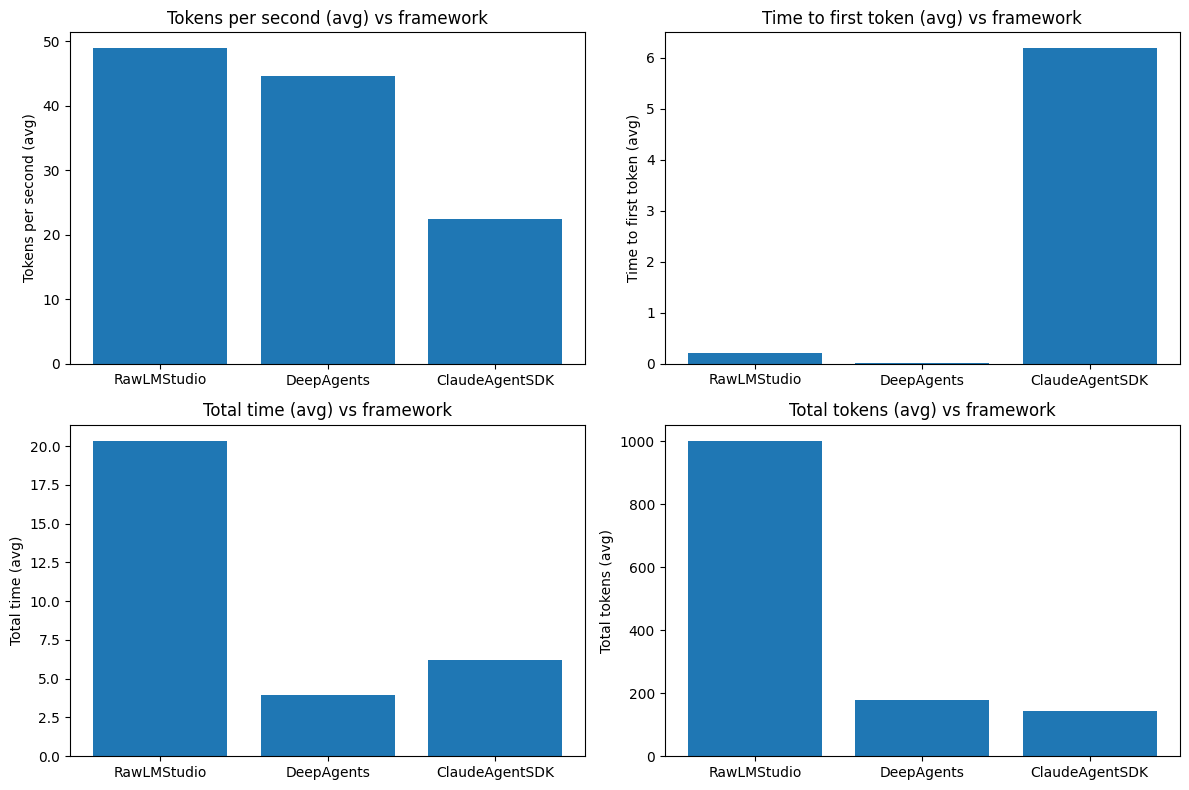

In [118]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

ax = axes[0, 0]
ax.bar(
    ["RawLMStudio", "DeepAgents", "ClaudeAgentSDK"],
    [
        avg_lm_studio["tokens_per_second_avg"],
        avg_deepagent["tokens_per_second_avg"],
        avg_claude["tokens_per_second_avg"],
    ],
)
ax.set_title("Tokens per second (avg) vs framework")
ax.set_ylabel("Tokens per second (avg)")

ax = axes[0, 1]
ax.bar(
    ["RawLMStudio", "DeepAgents", "ClaudeAgentSDK"],
    [
        avg_lm_studio["time_to_first_token_avg"],
        avg_deepagent["time_to_first_token_avg"],
        avg_claude["time_to_first_token_avg"],
    ],
)
ax.set_title("Time to first token (avg) vs framework")
ax.set_ylabel("Time to first token (avg)")

ax = axes[1, 0]
ax.bar(
    ["RawLMStudio", "DeepAgents", "ClaudeAgentSDK"],
    [
        avg_lm_studio["total_time_avg"],
        avg_deepagent["total_time_avg"],
        avg_claude["total_time_avg"],
    ],
)
ax.set_title("Total time (avg) vs framework")
ax.set_ylabel("Total time (avg)")

ax = axes[1, 1]
ax.bar(
    ["RawLMStudio", "DeepAgents", "ClaudeAgentSDK"],
    [
        avg_lm_studio["total_tokens_avg"],
        avg_deepagent["total_tokens_avg"],
        avg_claude["total_tokens_avg"],
    ],
)
ax.set_title("Total tokens (avg) vs framework")
ax.set_ylabel("Total tokens (avg)")

fig.tight_layout()
plt.show()


In [114]:
# plt.figure(figsize=(6,4))
# plt.bar(
#     ["RawLMStudio", "DeepAgents", "ClaudeAgentSDK"],
#     [
#         avg_lm_studio["tokens_per_second_avg"],
#         avg_deepagent["tokens_per_second_avg"],
#         avg_claude["tokens_per_second_avg"],
#     ],
# )
# plt.title("Tokens per second (avg) vs framework")
# plt.ylabel("Tokens per second (avg)")
# plt.show()

In [115]:
# plt.figure(figsize=(6,4))
# plt.bar(
#     ["RawLMStudio", "DeepAgents", "ClaudeAgentSDK"],
#     [
#         avg_lm_studio["time_to_first_token_avg"],
#         avg_deepagent["time_to_first_token_avg"],
#         avg_claude["time_to_first_token_avg"],
#     ],
# )
# plt.title("Time to first token (avg) vs framework")
# plt.ylabel("Time to first token (avg)")
# plt.show()

In [117]:
# plt.figure(figsize=(6,4))
# plt.bar(
#     ["RawLMStudio", "DeepAgents", "ClaudeAgentSDK"],
#     [
#         avg_lm_studio["total_time_avg"],
#         avg_deepagent["total_time_avg"],
#         avg_claude["total_time_avg"],
#     ],
# )
# plt.title("Total time (avg) vs framework")
# plt.ylabel("Total time (avg)")
# plt.show()

In [119]:
# plt.figure(figsize=(6,4))
# plt.bar(
#     ["RawLMStudio", "DeepAgents", "ClaudeAgentSDK"],
#     [
#         avg_lm_studio["total_tokens_avg"],
#         avg_deepagent["total_tokens_avg"],
#         avg_claude["total_tokens_avg"],
#     ],
# )
# plt.title("Total tokens (avg) vs framework")
# plt.ylabel("Total tokens (avg)")
# plt.show()

In [70]:
def get_prompt_id_results(id, data):
    results = []
    for item in data:
        # print(item)
        if item['prompt_id'] == id:
            results.append(item)
    return results


In [85]:
lm_runs_prompt_0 = get_prompt_id_results(0, raw_lm_studio_results)
lm_runs_prompt_1 = get_prompt_id_results(1, raw_lm_studio_results)
lm_runs_prompt_2 = get_prompt_id_results(2, raw_lm_studio_results)

deepagents_runs_prompt_0 = get_prompt_id_results(0, raw_deepagent_results)
deepagents_runs_prompt_1 = get_prompt_id_results(1, raw_deepagent_results)
deepagents_runs_prompt_2 = get_prompt_id_results(2, raw_deepagent_results)

claude_runs_prompt_0 = get_prompt_id_results(0, raw_claude_agent_sdk_results)
claude_runs_prompt_1 = get_prompt_id_results(1, raw_claude_agent_sdk_results)
claude_runs_prompt_2 = get_prompt_id_results(2, raw_claude_agent_sdk_results)

In [89]:
# print(lm_runs_prompt_0)

def get_average_metrics(data):
    results_time_to_first_token = []
    results_total_time = []
    results_tokens_per_second = []

    for result in data[1:]:
        results_time_to_first_token.append(result["time_to_first_token_s"])
        results_total_time.append(result["total_time_s"])
        results_tokens_per_second.append(result["tokens_per_second"])

    time_to_first_token_avg = sum(results_time_to_first_token) / len(results_time_to_first_token)
    total_time_avg = sum(results_total_time) / len(results_total_time)
    tokens_per_second_avg = sum(results_tokens_per_second) / len(results_tokens_per_second)

    print(f"Average time to first token: {time_to_first_token_avg:.3f} seconds")
    print(f"Average total time: {total_time_avg:.3f} seconds")
    print(f"Average tokens per second: {tokens_per_second_avg:.3f}")



In [92]:
get_average_metrics(lm_runs_prompt_2)

Average time to first token: 0.205 seconds

Average total time: 21.198 seconds

Average tokens per second: 51.184